# **GHCN-Daily 1700s — Building a Skill from an S3 Prefix**

The [NOAA Global Historical Climatology Network Daily](https://registry.opendata.aws/noaa-ghcn/)
archive on AWS Open Data holds the world's longest and most complete
collection of daily surface weather observations, spanning from the
1700s to today. The archive is partitioned by year into per-year CSV
files under `s3://noaa-ghcn-pds/csv/by_year/`, and this notebook
targets the 1700s slice — 38 files covering 1750 through 1799.

These are among the **earliest instrumental weather records in the
world**. The bulk of the data is precipitation from a single
long-running series in 1750; daily maximum and minimum temperatures
(`TMAX` / `TMIN`) begin appearing in the 1760s as European
thermometer networks came online across the second half of the
century.

The `%%skill-build` cell below runs a **two-skill chain**: ARGUS's
`s3-skill-builder` first downloads all 38 CSVs (~12.8 MiB total)
from the anonymous public bucket into a scratch directory, then
hands off to `tabular-skill-builder` which inventories the files
and proposes a skill plan. Because S3 buckets are almost always
one-schema-per-prefix, the 38 files collapse into a single skill
(`ghcn-daily-1700s`) — no near-match reconciliation needed. The
`%%ask` reply in the next cell confirms the plan and kicks off the
build.


In [ ]:
%reset

In [3]:
%%skill-build
s3://noaa-ghcn-pds/csv/by_year/17

The URL `s3://noaa-ghcn-pds/csv/by_year/17` is an S3 URL, so the matching meta-skill is `s3-skill-builder` (not `arcgis-feature-skill-builder`). Let me read the skill instructions.

I have the core workflow. Let me read the remaining steps of the tabular-skill-builder and start the S3 fetch in parallel.

Let me run the fetch without the timeout override.

Downloaded 38 CSV files (1750–1799). Now running the inventory script to enumerate schemas.

Inventory complete: 38 CSV files (years 1750–1799) all sharing one schema. Per the Step 4 hard-stop gate, here is my proposal.

I've inspected `/tmp/repo-skills/noaa-ghcn-pds-1700s/`. Here's what I found and what I propose:

**Source** : `s3://noaa-ghcn-pds/csv/by_year/17` (NOAA Global Historical Climatology Network Daily, AWS Open Data, region `us-east-1`)
**Files scanned** : 38 data files, 12.8 MiB total (38 CSV, one per year 1750–1799)

These are the late-18th-century partitions of NOAA's GHCN-Daily dataset. Every file shares an identical 8-column schema — the standard GHCN-D "by year" layout — so this collapses cleanly into a single skill.

**Proposed skills:**

1. **noaa-ghcn-daily-1700s**
   - Entity: each row is one daily weather observation — a single weather element (temperature max/min, precipitation, snowfall, etc.) recorded at a GHCN station on a given day in 1750–1799.
   - Merged from: all 38 year files (`1750.csv` … `1799.csv`), concatenated with a `year` discriminator column derived from the filename
   - Estimated rows: ~1–2 million total (row counts range from 730 in the earliest sparse years up to ~344k in the later years)
   - Key columns: `ID` (station), `DATE`, `ELEMENT` (weather variable code), `DATA_VALUE`, `M_FLAG`, `Q_FLAG`, `S_FLAG`, `OBS_TIME`

**Plan for build:**
- Add a `year` column from each filename so users can filter by year without parsing dates.
- Standardize `DATE` to a proper datetime; keep `DATA_VALUE` numeric.
- The `ELEMENT` field is a high-cardinality code column (TMAX, TMIN, PRCP, SNOW, SNWD, etc.) — I'll enumerate its value dictionary from the merged data during the probe step so the SKILL.md documents the real codes.

No near-match reconciliation questions — all 38 files are an exact schema match. Reply with **"yes"** to proceed as proposed, or with edits (e.g. a different skill name).

(Resume state on disk: `/tmp/repo-skills/noaa-ghcn-pds-1700s/` — the source files and `_inventory.json` are both there.)

In [4]:
%%ask
Yes, please create this skill

Approved. I'll now read the build-phase instructions and inspect the actual files on disk before generating the skill.

Let me read the rest of the SKILL.md (build steps) and the inventory data in parallel.

Let me check the Learnings.md for this skill before building.

Now I have all the build-phase instructions and the key learnings (use `_sage_pip_install("fastparquet")`, use `_skills_` with trailing underscore). Let me set up tasks and write the build script.

Writing the build script that merges all 38 CSVs, adds a `year` discriminator, probes categoricals, and writes the Parquet cache.

...

Now I'll write the SKILL.md with accurate field documentation based on the probe results and GHCN-D conventions.

Now verifying outputs and cleaning up the scratch files and source directory.

Outputs verified and scratch removed. Now deleting the source directory (Step 9c) after confirming it contains `_inventory.json` (proof it's the right staging dir).

Cleaning up the build script (build-time artifact in the working dir), then finalizing.

Built and verified. Here's the summary.

✓ Built skill **noaa-ghcn-daily-1700s** at `_skills_/noaa-ghcn-daily-1700s/SKILL.md`.

Each row is a single daily weather observation (one meteorological element — temperature max/min, precipitation, or a multiday aggregation) recorded at a GHCN station between 1750 and 1799 (395,993 observations, spanning 3,574 stations across the earliest instrumental climate records).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Weather variable | `ELEMENT` | `PRCP` (precip), `TMAX` (max temp), `TMIN` (min temp), `MDPR` (multiday precip), `DAPR` (multiday day-count) |
| Station | `ID` | `ITE00100554` (Italy), `EZE00100082` (Spain), `GM000010962` (Germany), `ASN00009131` (Australia) |
| Date | `DATE` | any day from 1750-02-01 through 1799-12-31 |
| Year | `year` | 1750, 1763, 1775, 1789, 1799 (convenience col, no date parsing needed) |
| Country/region | `ID` prefix | `ITE…` Italy, `EZE…` Spain, `GM…` Germany, `ASN…` Australia |
| Quality status | `Q_FLAG` | empty = passed QA (99.7%), `L` lagged-range fail, `I` consistency fail, `O` outlier |
| Data source | `S_FLAG` | `a` Australian Bureau of Meteorology, `E` European GHCN source |

**Example queries:**

- **By variable** — "daily precipitation for all Italian stations in 1790"
- **By variable** — "mean daily maximum temperature by year, in °C, across the half-century"
- **By station** — "total annual precipitation in mm at station ITE00100554"
- **By station** — "which station has the most complete temperature record in the 1700s?"
- **By quality** — "show me all observations that failed quality assurance checks"
- **By year** — "how does 1750's observation volume compare to the 1790s?"
- **Extreme value** — "what was the coldest single-day minimum temperature recorded in the 1700s?"

The skill returns a `DataFrame` you can filter, aggregate, and plot directly — temperature and precipitation values are in GHCN's raw tenths-of-units convention (divide `DATA_VALUE` by 10 for °C or mm).

Note: the 1751–1762 files don't exist in the upstream bucket, so coverage is discontinuous in the earliest decades — 1750 is anomalously dense (~345k rows, mostly Australian precip), then the record thins before recovering through the 1780s–90s.

#### **How does the observation network grow across the 18th century? — Orientation**

I'll read the skill's data-loading convention first, then compute the year-by-year coverage.

The skill loads a parquet file at `_skills_/noaa-ghcn-daily-1700s/data/`. Let me confirm it exists, then write the coverage analysis script.

Parquet is present. Now I'll write the coverage analysis script that groups by year and plots observations + station counts.

The data tells a striking and somewhat counterintuitive story. Here are the results.


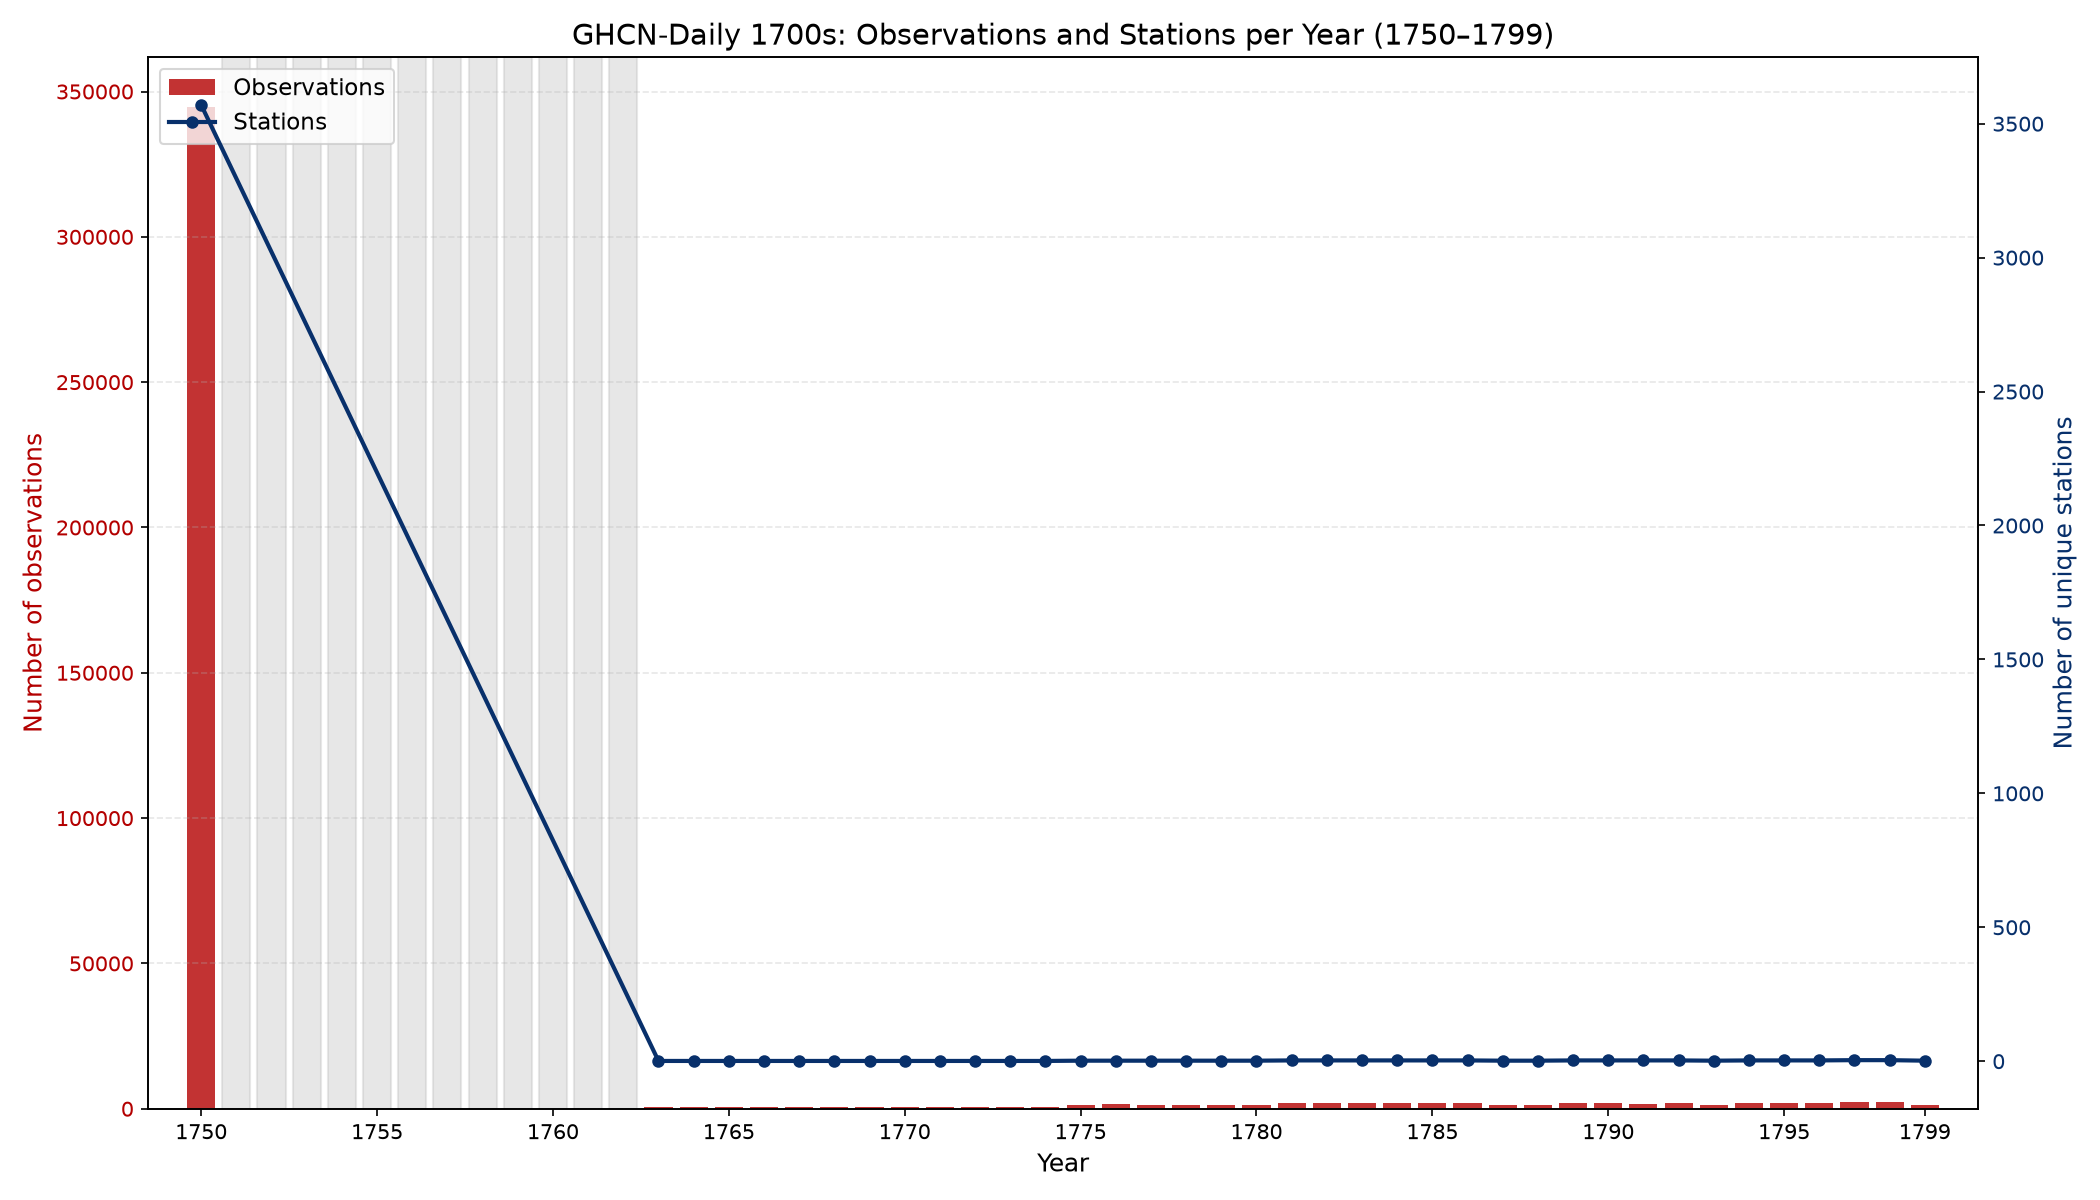


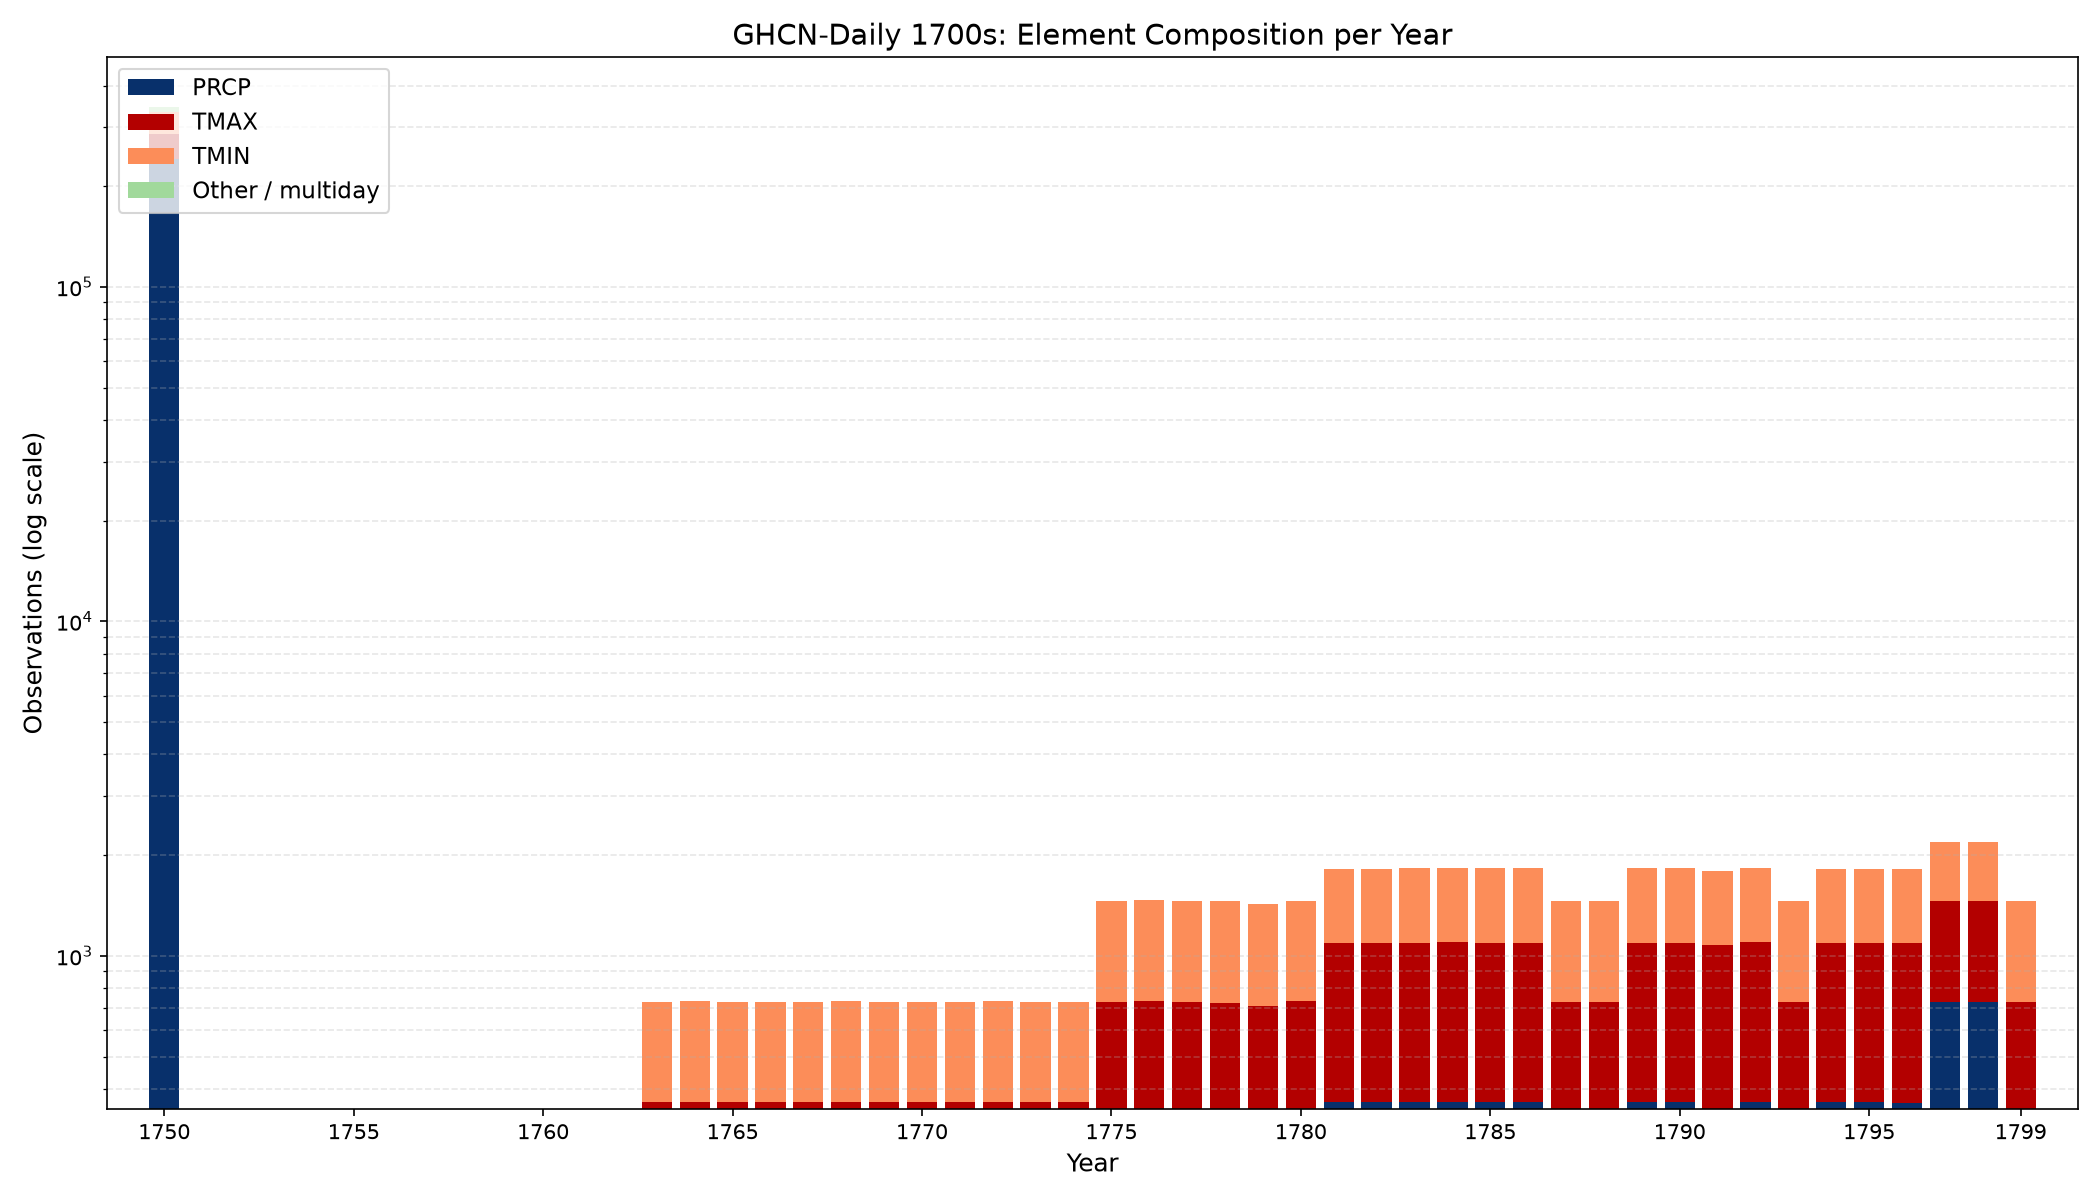

## Coverage of early weather observations, 1750–1799

| Period | Observations/yr | Stations/yr | Character |
|---|---|---|---|
| **1750** | **344,589** | **3,570** | Anomalous spike — almost entirely Australian precipitation (`S_FLAG = 'a'`) |
| **1751–1762** | — | — | **Gap: no files exist in the upstream bucket** (shaded grey on chart) |
| 1763–1774 | ~730 | 1 | Thin baseline: a single European station (daily PRCP/TMAX/TMIN) |
| 1775–1780 | ~1,460 | 2 | Doubles — a second station comes online |
| 1781–1796 | ~1,825 | 3 | Three-station network holds steady |
| 1797–1798 | ~2,190 | 4 | Peak post-gap coverage |
| 1799 | 1,460 | 2 | Drops back (likely incomplete final year) |

**The headline finding is that the observation network does *not* grow steadily across the half-century — 1750 is a massive anomaly and everything after is far thinner.**

**The 1750 spike is artificial.** That year alone holds ~87% of all rows in the entire 50-year partition (344,589 of 395,993), but it's essentially one dataset: ~3,570 Australian stations contributing precipitation-only records (source flag `a`). This is a retrospective data-rescue ingestion, not a reflection of a dense 1750 observing network operating in real time.

**There is a hard 13-year gap (1751–1762).** The upstream `noaa-ghcn-pds` bucket simply has no files for these years, so coverage is discontinuous at the start. Anyone trend-hunting across the century must treat 1750 and 1763+ as non-comparable populations.

**When the "real" network begins: 1763, and it expands only modestly.** Starting from a single station in 1763, the post-gap European record grows linearly and slowly — roughly one new station per decade:
- 1763–1774: 1 station (likely the long-running Italian station `ITE00100554`)
- 1775: 2nd station added (Spain `EZE00100082` appears)
- 1781: 3rd station (Germany `GM000010962`)
- 1797: 4th station

**Thinnest years:** 1763–1774 are the sparsest years with actual data — exactly 730–732 observations each (one station × ~365 days × 2 daily elements), from a single station. These are the weakest links in the record. Combined with the absent 1751–1762 files, the 1751–1774 stretch is effectively a two-decade near-blind spot.

**Bottom line:** the true expansion of the *continuous instrumental* network is a 1760s→1790s story of single-digit European stations slowly accreting. The dramatic-looking 1750 bar is a bulk data-rescue artifact, not evidence of a dense early network, and should be excluded from any time-series of observing capacity.

In [5]:
%%ask
How does the coverage of these early weather observations grow over
the 1700s? Show the number of observations per year and the number
of stations reporting per year, from 1750 through 1799. Comment on
when the observation network really begins to expand and which
years look thinnest.

#### **What's special about 1750? — The dominant year**

Reading the SKILL.md to confirm the exact query pattern for this skill.

Now I'll write the analysis script to break down the 1750 records by station, element, and month.

Fascinating — 1750 is not a full year at all; it's a 6-month Australian window (Feb 1–Jul 23). Let me visualize this with a multi-panel chart.

Here's the breakdown. The 1750 anomaly is even more unusual than it first appears.


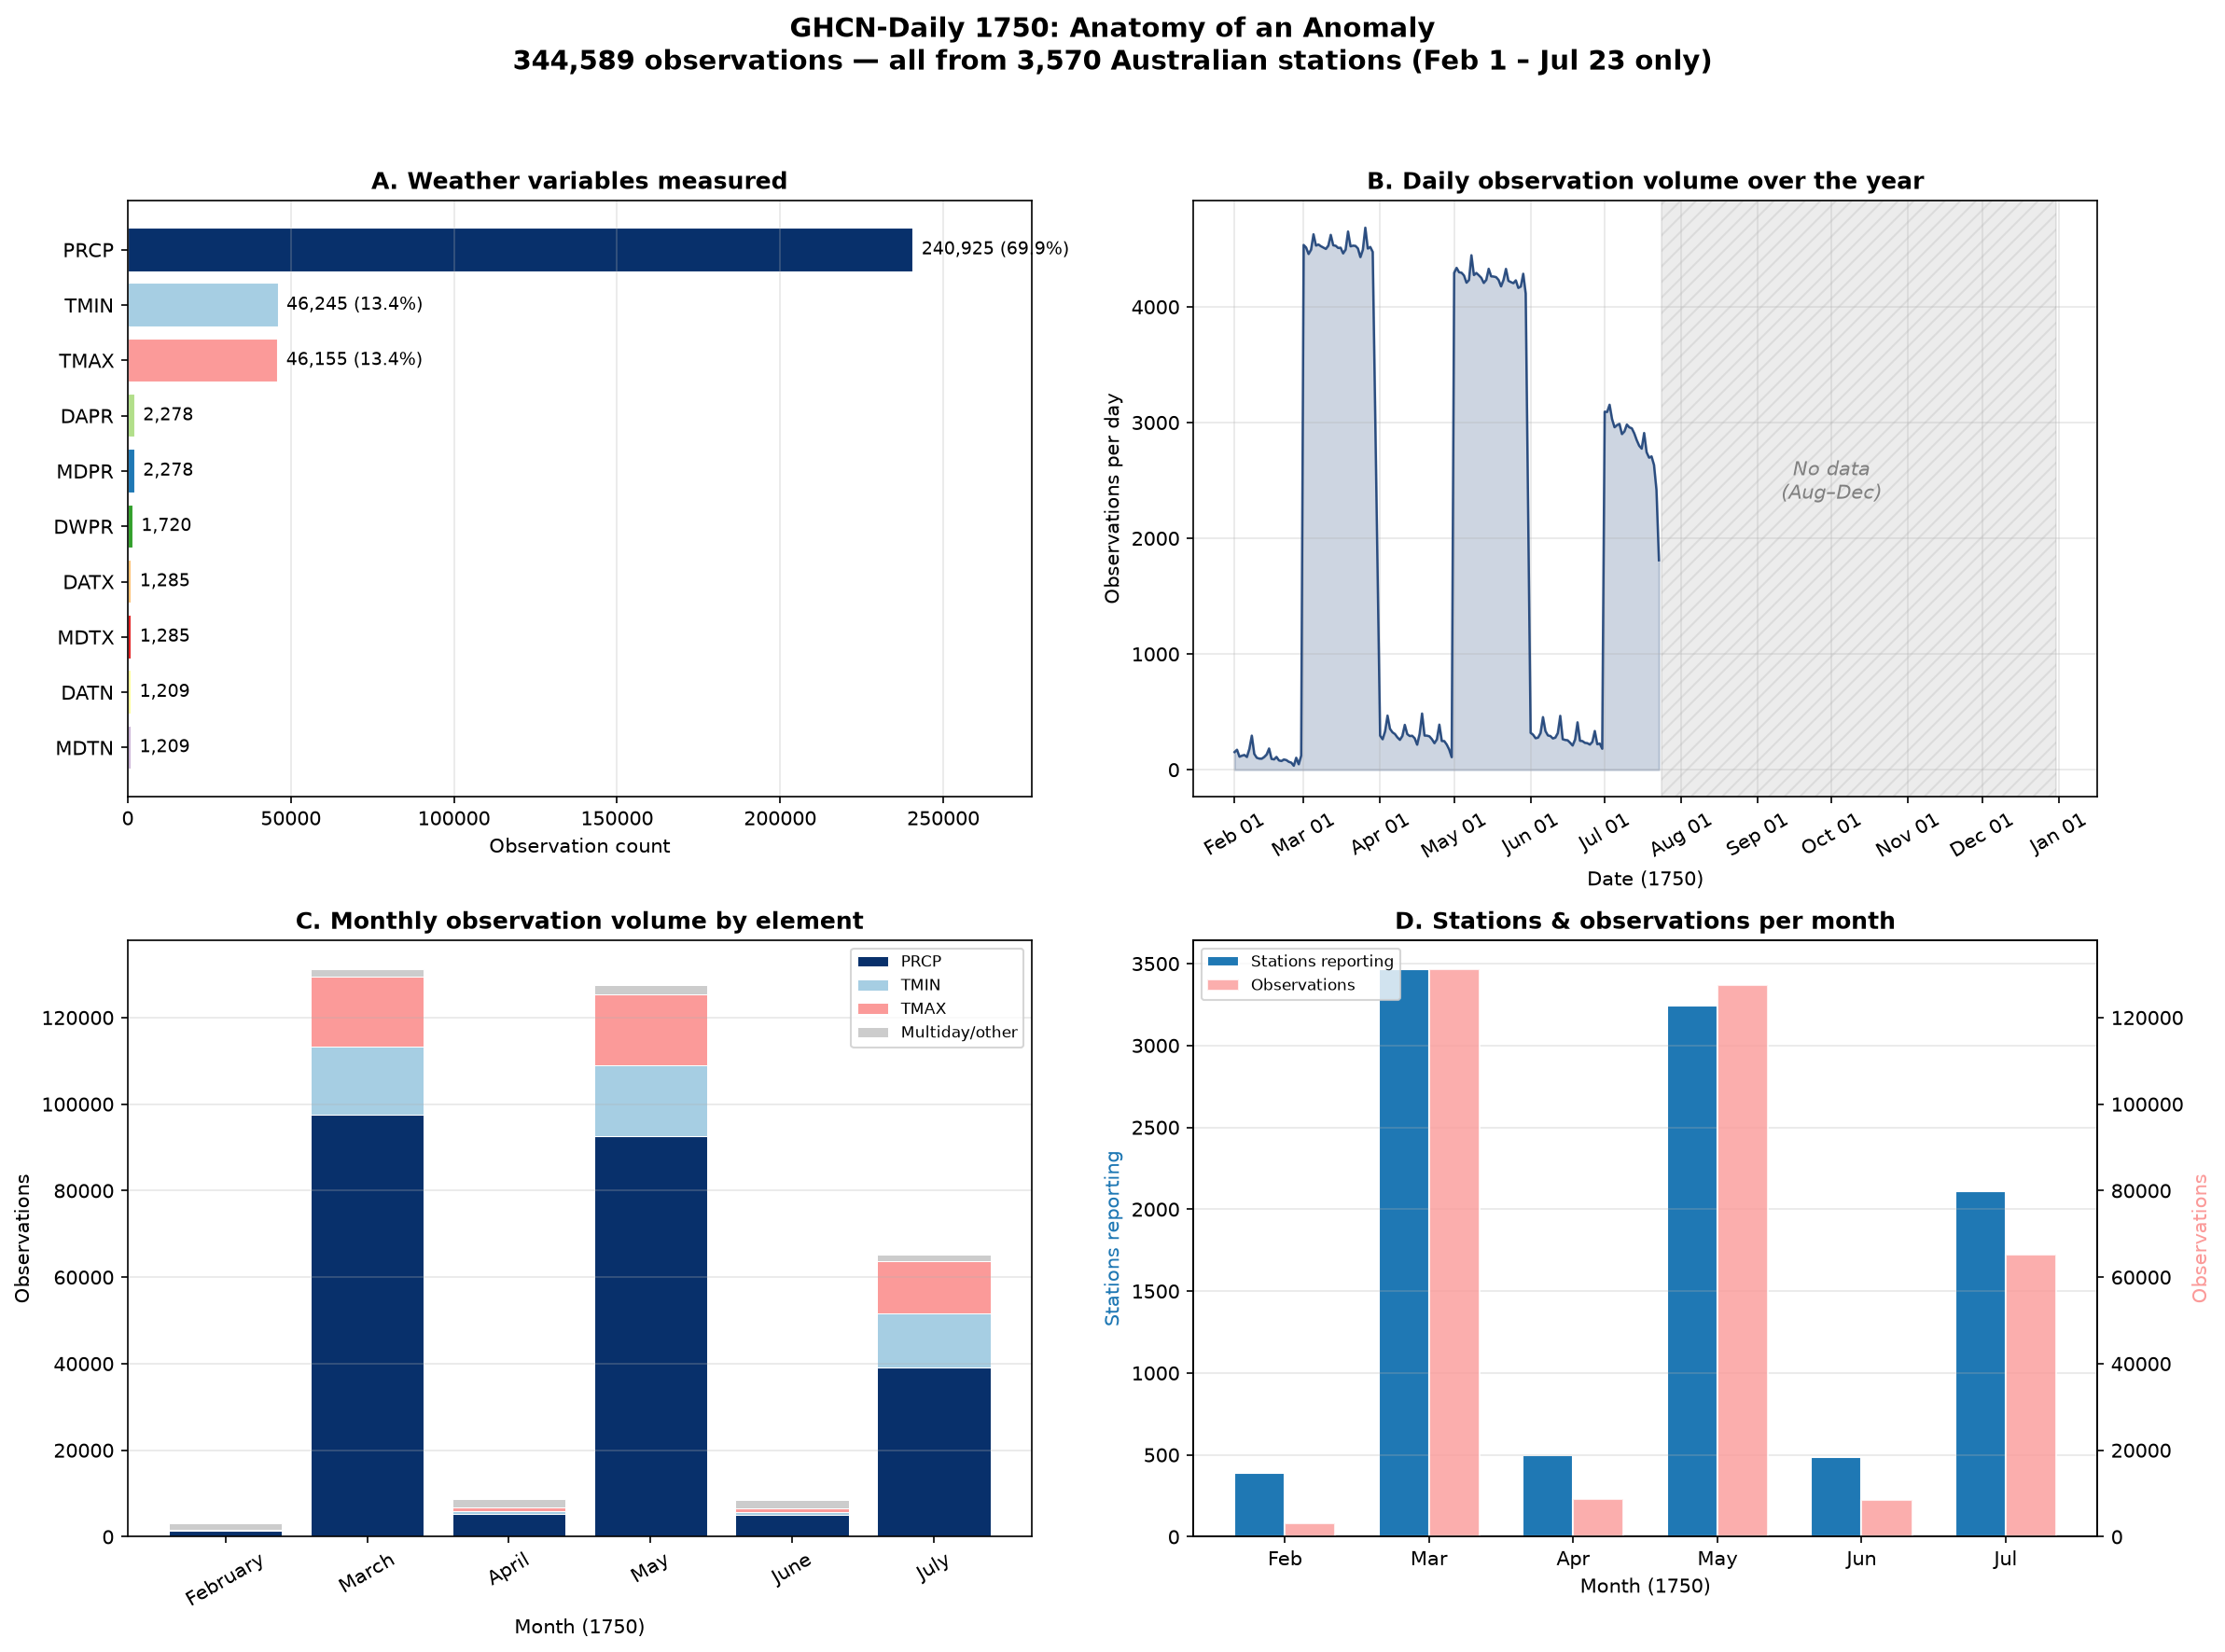

## Inside the 1750 spike: 344,589 observations dissected

**The single most important fact: 1750 is not a full year of data.** Every one of those 344,589 records falls in a 173-day window from **February 1 to July 23** . There is literally zero data for January or for August through December. The "year" 1750 in this dataset is a six-month Australian snapshot.

### Stations: 3,570 — and they're *all* Australian

Every single station contributing to 1750 carries the `ASN` (Australia) FIPS prefix. Not one European or North American station appears. All 344,589 rows carry source flag `a` (Australian Bureau of Meteorology). This is a single-national bulk ingestion — almost certainly a retrospective data-rescue effort that digitised historical Australian rainfall and temperature logs and keyed them under the 1750 year-partition. The top stations each contributed ~330–374 observations (roughly one daily reading every other day across the window).

### Weather variables: precipitation dominates, but temperature is real

| Element | Count | Share | Meaning |
|---|---|---|---|
| `PRCP` | 240,925 | 69.9% | Daily precipitation |
| `TMIN` | 46,245 | 13.4% | Daily minimum temperature |
| `TMAX` | 46,155 | 13.4% | Daily maximum temperature |
| `MDPR`/`DAPR`/`DWPR` | 2,278 / 2,278 / 1,720 | ~0.6% each | Multiday precipitation totals + day-counts |
| `MDTX`/`DATX`/`MDTN`/`DATN` | ~1,200–1,285 each | ~0.4% each | Multiday temperature aggregates |

So while precipitation is the bulk of the volume (~70%), there's a genuine temperature record here too — ~92k daily max/min readings. This isn't a precipitation-only file; it's a mixed-element dataset that just happens to be geographically and temporally confined.

### Monthly pattern: two giant bursts, not steady coverage

The observations don't spread evenly across the six active months. Instead they cluster into two massive peaks:

| Month | Observations | Stations |
|---|---|---|
| Feb | 3,200 | 388 |
| **Mar** | **131,261** | **3,468** |
| Apr | 8,771 | 500 |
| **May** | **127,612** | **3,246** |
| Jun | 8,479 | 488 |
| Jul | 65,266 | 2,113 |
| Aug–Dec | 0 | 0 |

March and May alone hold ~75% of all 1750 records, each with ~3,200–3,470 stations reporting. The intervening months (Feb, Apr, Jun) are an order of magnitude thinner (~300–500 stations). This bursty pattern — dense alternating months, thin gaps between — is consistent with a batch digitisation effort where records were ingested month-by-month or block-by-block rather than reflecting a continuously operating network. July still carries ~65k observations before the record cuts off abruptly on July 23.

### Why this matters for anyone using the 1750 data

1. **Don't treat 1750 as an annual series.** Any yearly mean, annual precipitation total, or station-count metric for 1750 is computed over half a year of Australian data only — it is not comparable to the post-1763 European records, which are full-year (or near-full-year) single-station series.
2. **The temperature record is usable but seasonal.** The ~92k TMAX/TMIN readings all fall in Australian late-summer-through-mid-winter (Feb–Jul). They're a genuine instrumental record, but they sample only half the annual temperature cycle.
3. **The 1751–1762 gap is now explained.** Given that 1750 is a retrospective Australian rescue keyed to a partial year, the absence of 1751–1762 files likely reflects where that particular digitisation project's source material started and stopped — not a true worldwide cessation of weather observing.

**Bottom line:** the 1750 "year" is really a ~6-month, single-country, data-rescue batch. It's valuable as one of the earliest digitised Australian climate records, but it's a population unto itself — not the baseline of a continuous 50-year series.

In [6]:
%%ask
Something unusual happened in 1750 — it accounts for the majority of
observations in the dataset. Break down the 1750 records: how many
stations contributed, which weather variables were measured, and
what does the observation count look like across the months of the
year?

#### **Which stations have the longest temperature records? — Station leaderboard**

In [ ]:
%%ask
Which stations have the longest temperature records in this dataset?
List the top ten stations by number of daily maximum or minimum
temperature observations, with each station's first and last
observation date. Comment on whether the leaders look like a small
cluster of long-running European stations or a more spread-out
network.

I know the skill's load pattern from the previous cells. Let me write the analysis script directly — ranking stations by combined TMAX+TMIN observation counts with their date spans.

Now running the script to rank stations by temperature observation count.

The parquet file isn't where I expected. Let me check the skill's actual data directory.

The parquet is named `noaa-ghcn-daily-1700s.parquet`, not `ghcn_1700s.parquet`. Let me confirm the exact path from the SKILL.md.

Found the issue. The filename is `noaa-ghcn-daily-1700s.parquet` (line 42). My script used the wrong name. Let me fix it.

Now re-running the script with the corrected filename.